Gold recovery is a critical industrial process, where even small improvements in efficiency can lead to significant economic impact. In this project, we analyze data from a gold ore purification process to build a model that predicts recovery efficiency at different stages of production. The objective is to accurately forecast both the rougher concentrate recovery and the final concentrate recovery, enabling better operational control and optimization.

The dataset consists of time-indexed process parameters collected at multiple stages of purification, including raw feed, rougher processing, and final concentration. Due to real-world constraints, some features are unavailable in the test set because they are measured or calculated after the target values are formed. This reflects a realistic production environment and requires careful feature selection and preprocessing.

The project follows a structured workflow: validating the correctness of recovery calculations, preprocessing and analyzing the data, exploring how metal concentrations evolve through purification stages, and training multiple machine learning models. Model performance is evaluated using the symmetric Mean Absolute Percentage Error (sMAPE), which appropriately penalizes prediction errors relative to true values. The final goal is to select a robust model that generalizes well and provides reliable recovery predictions on unseen data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor



# 1.1

In [2]:

train = pd.read_csv('/datasets/gold_recovery_train.csv')
# print(train)


In [3]:
test = pd.read_csv('/datasets/gold_recovery_test.csv')
#print(test)


In [4]:
full = pd.read_csv('/datasets/gold_recovery_full.csv')
#print(full)

# 1.2

In [5]:






print(train['rougher.input.feed_au'].isnull().sum())
print(train['rougher.output.concentrate_au'].isnull().sum())
print(train['rougher.output.tail_au'].isnull().sum())
print(train['rougher.output.recovery'].isnull().sum())



train[
    ['rougher.input.feed_au',
    'rougher.output.concentrate_au',
     'rougher.output.tail_au',
     'rougher.output.recovery']
].isna().mean() * 100



83
82
2249
2573


rougher.input.feed_au             0.492289
rougher.output.concentrate_au     0.486358
rougher.output.tail_au           13.339265
rougher.output.recovery          15.260973
dtype: float64

count    16777.000000
mean         7.170717
std          3.002113
min          0.000000
25%          6.203083
50%          7.443530
75%          8.965193
max         14.093363
Name: rougher.input.feed_au, dtype: float64
count    16778.000000
mean        17.401541
std          6.921875
min          0.000000
25%         17.443663
50%         19.644663
75%         21.224486
max         28.522811
Name: rougher.output.concentrate_au, dtype: float64
count    14611.000000
mean         1.763930
std          0.731518
min          0.020676
25%          1.311610
50%          1.747907
75%          2.190839
max          9.688980
Name: rougher.output.tail_au, dtype: float64
count    14287.000000
mean        82.394201
std         15.096808
min          0.000000
25%         79.818372
50%         85.235997
75%         90.131691
max        100.000000
Name: rougher.output.recovery, dtype: float64


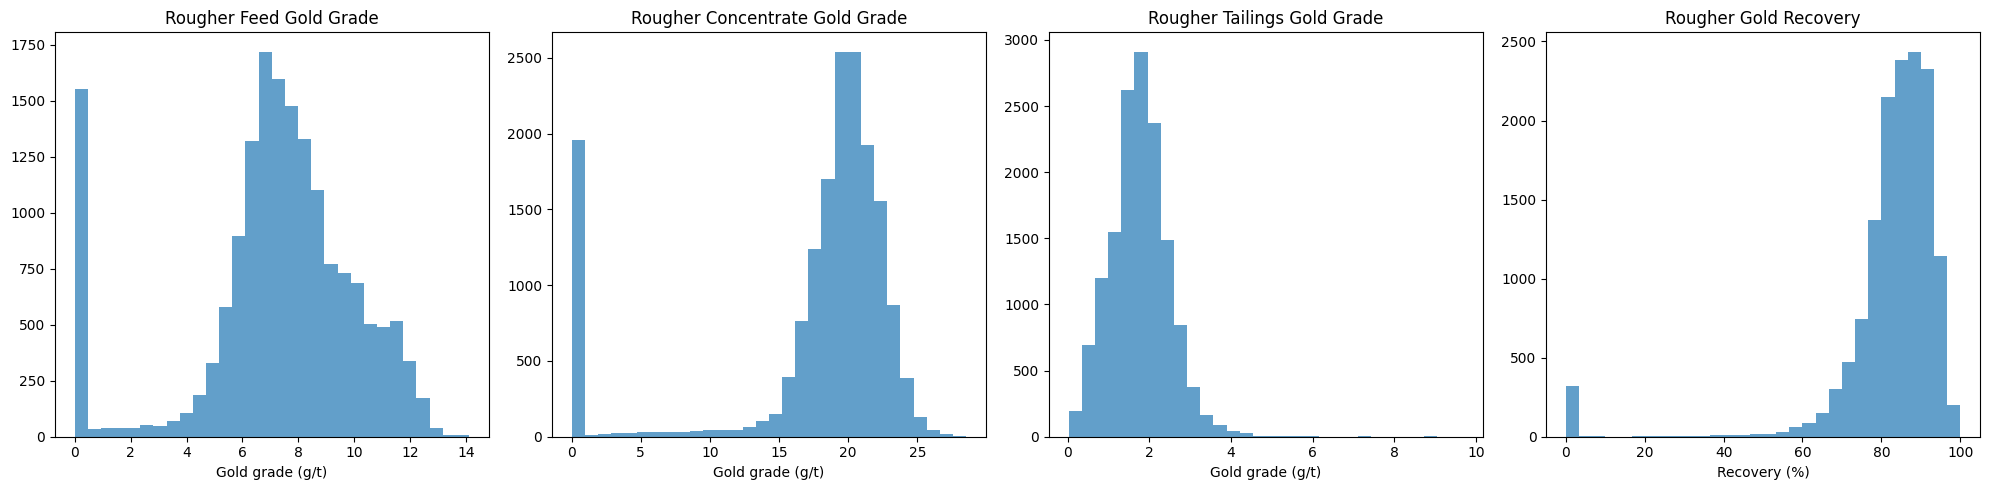

In [6]:


print(train['rougher.input.feed_au'].describe())

print(train['rougher.output.concentrate_au'].describe())
print(train['rougher.output.tail_au'].describe())
print(train['rougher.output.recovery'].describe())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(train['rougher.input.feed_au'], bins=30, alpha=0.7)
axes[0].set_title('Rougher Feed Gold Grade')
axes[0].set_xlabel('Gold grade (g/t)')

axes[1].hist(train['rougher.output.concentrate_au'], bins=30, alpha=0.7)
axes[1].set_title('Rougher Concentrate Gold Grade')
axes[1].set_xlabel('Gold grade (g/t)')

axes[2].hist(train['rougher.output.tail_au'], bins=30, alpha=0.7)
axes[2].set_title('Rougher Tailings Gold Grade')
axes[2].set_xlabel('Gold grade (g/t)')

axes[3].hist(train['rougher.output.recovery'], bins=30, alpha=0.7)
axes[3].set_title('Rougher Gold Recovery')
axes[3].set_xlabel('Recovery (%)')

plt.tight_layout()
plt.show()


I initially attempted to calculate recovery directly on the training data while filtering out zeros and NAN since the recovery formula involves division. To simplify the process and ensure numerical stability, I instead created a cleaned copy of the dataset and removed NaN and null values before applying the recovery calculation which makes things simpler.

In [8]:
train_copy = train.copy()
train_copy.replace(0, np.nan, inplace=True)
train_copy.dropna(inplace=True)








Recovery = (C × (F - T)) / (F × (C - T)) × 100%











In [9]:


C_rougher = train_copy['rougher.output.concentrate_au']
F_rougher = train_copy['rougher.input.feed_au'] 
T_rougher = train_copy['rougher.output.tail_au']
calculated_recovery = (C_rougher * (F_rougher - T_rougher)) / (F_rougher * (C_rougher - T_rougher)) * 100




In [10]:




# Calculate MAE only on truly normal cases
stored_recovery = train_copy['rougher.output.recovery']




mae_normal_only = mean_absolute_error(stored_recovery, calculated_recovery)

print(f"MAE on truly normal cases: {mae_normal_only:.25f}")
print(f"Calculated recovery range (truly normal): {calculated_recovery.min():.9f} to {calculated_recovery.max():.2f}")


MAE on truly normal cases: 0.0000000000000096187520758
Calculated recovery range (truly normal): 2.520853803 to 99.98


The recalculated recovery values match the dataset almost exactly. The MAE is essentially zero, meaning any tiny difference is only due to rounding. The recovery values fall in a realistic range (about 2.5% to 100%), confirming the formula and the data are correct.

# 1.3

In [11]:
missing_in_test = sorted(set(train.columns) - set(test.columns))

print("Columns in train but NOT in test:")
for col in missing_in_test:
    print(col)

print(f"\nTotal missing columns: {len(missing_in_test)}")



Columns in train but NOT in test:
final.output.concentrate_ag
final.output.concentrate_au
final.output.concentrate_pb
final.output.concentrate_sol
final.output.recovery
final.output.tail_ag
final.output.tail_au
final.output.tail_pb
final.output.tail_sol
primary_cleaner.output.concentrate_ag
primary_cleaner.output.concentrate_au
primary_cleaner.output.concentrate_pb
primary_cleaner.output.concentrate_sol
primary_cleaner.output.tail_ag
primary_cleaner.output.tail_au
primary_cleaner.output.tail_pb
primary_cleaner.output.tail_sol
rougher.calculation.au_pb_ratio
rougher.calculation.floatbank10_sulfate_to_au_feed
rougher.calculation.floatbank11_sulfate_to_au_feed
rougher.calculation.sulfate_to_au_concentrate
rougher.output.concentrate_ag
rougher.output.concentrate_au
rougher.output.concentrate_pb
rougher.output.concentrate_sol
rougher.output.recovery
rougher.output.tail_ag
rougher.output.tail_au
rougher.output.tail_pb
rougher.output.tail_sol
secondary_cleaner.output.tail_ag
secondary_cleaner

The features missing from the test set are output and recovery parameters from different processing stages. These variables represent target values or post-processing results and are numerical, continuous features. They are intentionally excluded from the test set to prevent data leakage, since they would not be available at prediction time.

# 1.4

First, I print the distibution for some of the columns we worked with before and then we print out the zeors and NuN values for the whole dataset to give us perspective as we want the distribution to be similar after we filter and change the values so the functions can run.

count    16777.000000
mean         7.170717
std          3.002113
min          0.000000
25%          6.203083
50%          7.443530
75%          8.965193
max         14.093363
Name: rougher.input.feed_au, dtype: float64
count    16778.000000
mean        17.401541
std          6.921875
min          0.000000
25%         17.443663
50%         19.644663
75%         21.224486
max         28.522811
Name: rougher.output.concentrate_au, dtype: float64
count    14611.000000
mean         1.763930
std          0.731518
min          0.020676
25%          1.311610
50%          1.747907
75%          2.190839
max          9.688980
Name: rougher.output.tail_au, dtype: float64
count    14287.000000
mean        82.394201
std         15.096808
min          0.000000
25%         79.818372
50%         85.235997
75%         90.131691
max        100.000000
Name: rougher.output.recovery, dtype: float64


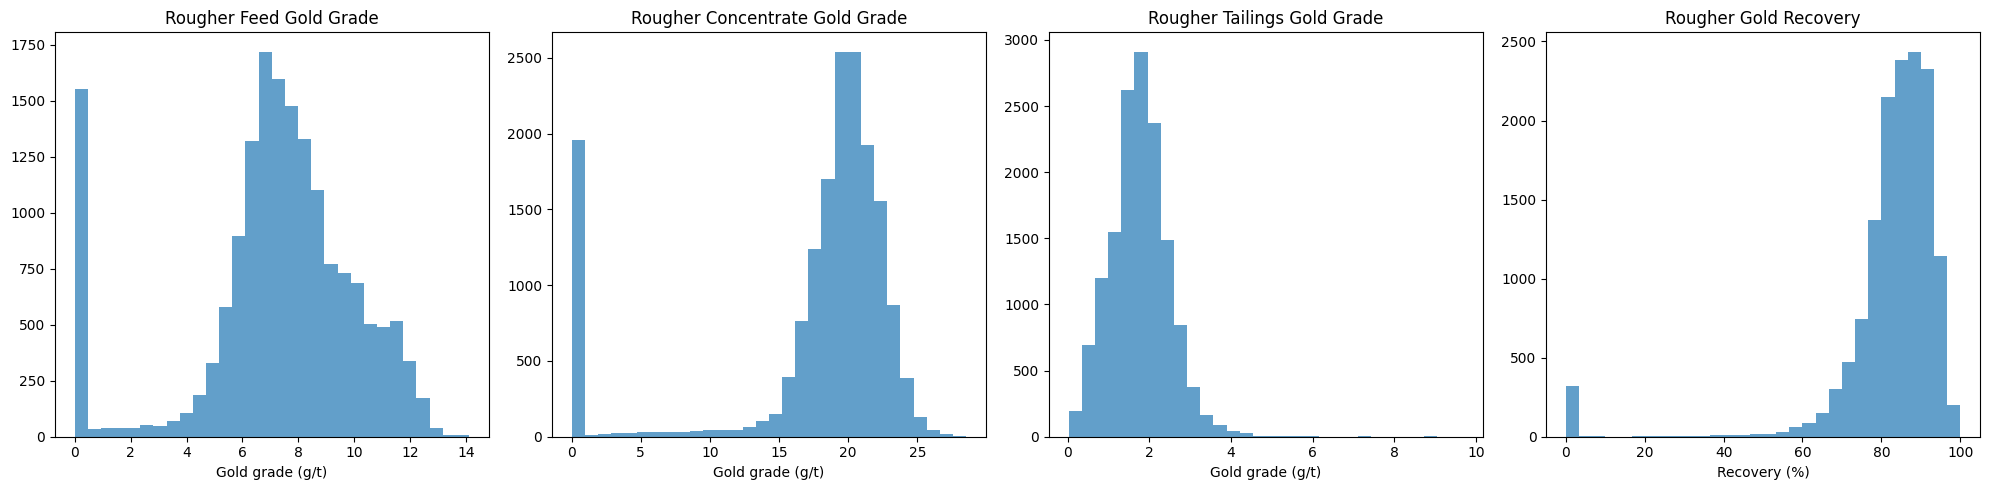

In [12]:

print(train['rougher.input.feed_au'].describe())

print(train['rougher.output.concentrate_au'].describe())
print(train['rougher.output.tail_au'].describe())
print(train['rougher.output.recovery'].describe())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(train['rougher.input.feed_au'], bins=30, alpha=0.7)
axes[0].set_title('Rougher Feed Gold Grade')
axes[0].set_xlabel('Gold grade (g/t)')

axes[1].hist(train['rougher.output.concentrate_au'], bins=30, alpha=0.7)
axes[1].set_title('Rougher Concentrate Gold Grade')
axes[1].set_xlabel('Gold grade (g/t)')

axes[2].hist(train['rougher.output.tail_au'], bins=30, alpha=0.7)
axes[2].set_title('Rougher Tailings Gold Grade')
axes[2].set_xlabel('Gold grade (g/t)')

axes[3].hist(train['rougher.output.recovery'], bins=30, alpha=0.7)
axes[3].set_title('Rougher Gold Recovery')
axes[3].set_xlabel('Recovery (%)')

plt.tight_layout()
plt.show()



In [13]:


total_rows = len(train)

summary = pd.DataFrame({
    'NaN_count': train.isna().sum(),
    'NaN_percent': train.isna().sum() / total_rows * 100,
    'Zero_count': (train == 0).sum(),
    'Zero_percent': (train == 0).sum() / total_rows * 100
})

# make all rows/columns visible
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(summary.head)


<bound method NDFrame.head of                                                     NaN_count  NaN_percent  \
date                                                        0     0.000000   
final.output.concentrate_ag                                72     0.427046   
final.output.concentrate_pb                                72     0.427046   
final.output.concentrate_sol                              370     2.194543   
final.output.concentrate_au                                71     0.421115   
final.output.recovery                                    1521     9.021352   
final.output.tail_ag                                       66     0.391459   
final.output.tail_pb                                      183     1.085409   
final.output.tail_sol                                     145     0.860024   
final.output.tail_au                                       66     0.391459   
primary_cleaner.input.sulfate                            1307     7.752076   
primary_cleaner.input.depressant  

We create target values that have the same index as test so we can run it the smape function later against predictions. 

In [14]:

print(test.shape)
target_test = full[['rougher.output.recovery', 'final.output.recovery']].loc[test.index]

rough_target_test = target_test['rougher.output.recovery']
print(rough_target_test.shape)
final_target_test = target_test['final.output.recovery']
print(final_target_test.shape)





(5856, 53)
(5856,)
(5856,)


For target variables like recovery rates, rows with values of 0 or NaN should be removed rather than filled. Zero values usually indicate abnormal conditions such as process failures or measurement errors, while NaN values mean the data is missing or unreliable. Filling target values would create artificial outcomes and mislead the model during training. Since these values do not represent normal operating conditions, removing them helps ensure the model learns from valid, realistic data and produces more accurate predictions.

In [15]:


print(train.shape)
print(full.shape)
print(test.shape)
# Clean train
train = train[
    (train['rougher.output.recovery'].notna()) &
    (train['rougher.output.recovery'] != 0) &
    (train['final.output.recovery'].notna()) &
    (train['final.output.recovery'] != 0)
]


full = full[
    (full['rougher.output.recovery'].notna()) &
    (full['rougher.output.recovery'] != 0) &
    (full['final.output.recovery'].notna()) &
    (full['final.output.recovery'] != 0)
]
print(train.shape)
print(full.shape)



(16860, 87)
(22716, 87)
(5856, 53)
(13795, 87)
(18949, 87)


In [16]:
valid_test_indices = target_test[
    (target_test['rougher.output.recovery'].notna()) &
    (target_test['rougher.output.recovery'] != 0) &
    (target_test['final.output.recovery'].notna()) &
    (target_test['final.output.recovery'] != 0)
].index

test = test.loc[valid_test_indices]
target_test = target_test.loc[valid_test_indices]
rough_target_test = target_test['rougher.output.recovery']
print(rough_target_test.shape)
final_target_test = target_test['final.output.recovery']
print(final_target_test.shape)
print(test.shape)

(4855,)
(4855,)
(4855, 53)


In [17]:

train = train.replace(0, np.nan)
train = train.fillna(method='bfill').fillna(method='ffill')





In [18]:
#remember to delete target values and not put them as 0' it messes up the data





## Now, we will do the same to the test data:

In [19]:
print(test.shape)



test = test.replace(0, np.nan)
test = test.fillna(method='bfill').fillna(method='ffill')


summary = pd.DataFrame({
    'NaN_count': test.isna().sum(),
    'NaN_percent': test.isna().sum() / total_rows * 100,
    'Zero_count': (test == 0).sum(),
    'Zero_percent': (test == 0).sum() / total_rows * 100
})


# make all rows/columns visible
print(test.shape)
#print(summary)

(4855, 53)
(4855, 53)


After applying forward fill (ffill) and backward fill (bfill), the feature distributions preserve more of their original shape compared to mean imputation. The histograms indicate smoother, more continuous distributions without artificial spikes at the mean. In contrast, mean imputation concentrates many values at a single point, distorts the distribution, and reduces natural variability. Since this dataset represents sequential process data, ffill and bfill better respect the underlying structure and temporal continuity of the measurements.

# 2.1


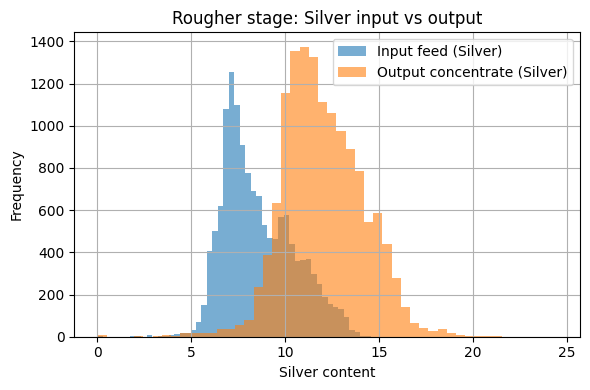

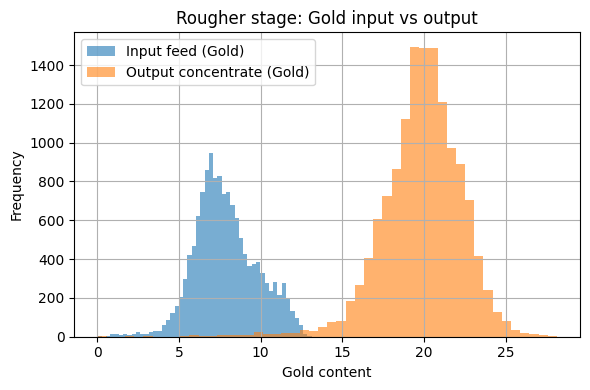

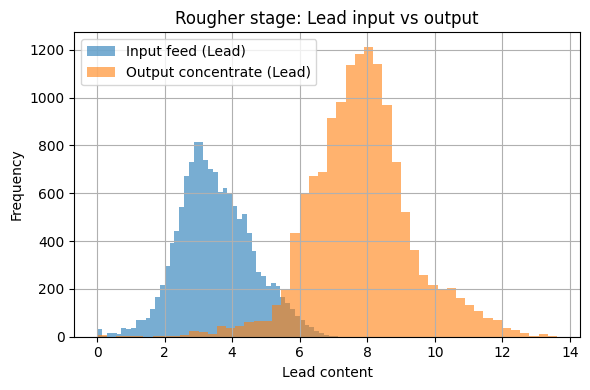

In [20]:


metals = {
    'ag': 'Silver',
    'au': 'Gold',
    'pb': 'Lead'
}

for metal, name in metals.items():
    plt.figure(figsize=(6,4))
    
    train[f'rougher.input.feed_{metal}'].hist(
        bins=50, alpha=0.6, label=f'Input feed ({name})'
    )
    train[f'rougher.output.concentrate_{metal}'].hist(
        bins=50, alpha=0.6, label=f'Output concentrate ({name})'
    )
    
    plt.title(f'Rougher stage: {name} input vs output')
    plt.xlabel(f'{name} content')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()






From the rougher stage to the first (primary cleaner) stage, the metal concentration increases. This indicates that the cleaning process successfully removes waste material and produces a more concentrated metal output.

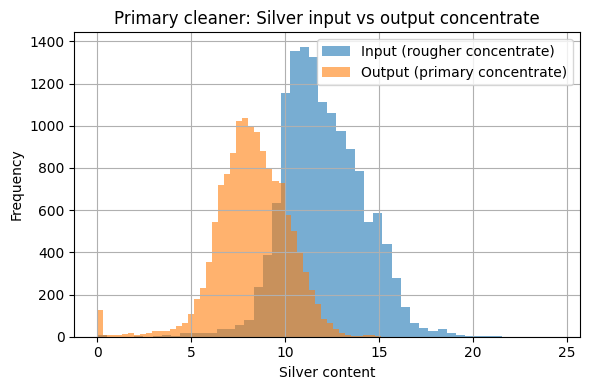

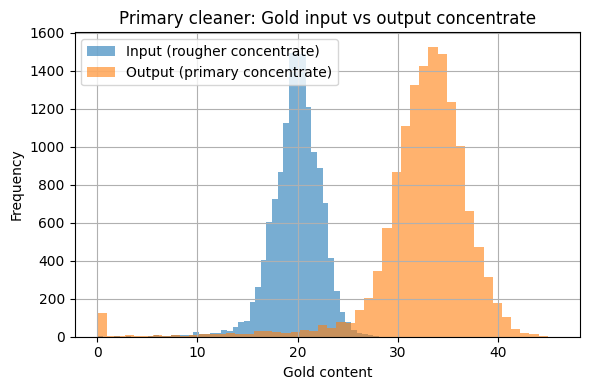

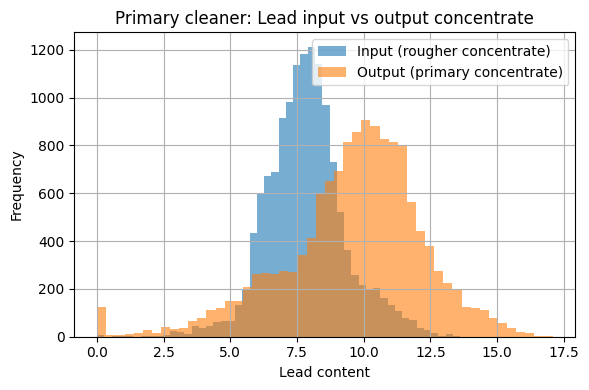

In [21]:






metal_names = {
    'ag': 'Silver',
    'au': 'Gold',
    'pb': 'Lead'
}

for metal in ['ag', 'au', 'pb']:
    plt.figure(figsize=(6,4))

    train[f'rougher.output.concentrate_{metal}'].hist(
        bins=50, alpha=0.6, label=f'Input (rougher concentrate)'
    )

    train[f'primary_cleaner.output.concentrate_{metal}'].hist(
        bins=50, alpha=0.6, label=f'Output (primary concentrate)'
    )

    plt.title(f'Primary cleaner: {metal_names[metal]} input vs output concentrate')
    plt.xlabel(f'{metal_names[metal]} content')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()



These graphs show that silver concentration decreases from the rougher stage to the primary cleaner, while gold and lead concentrations increase during the same purification step.

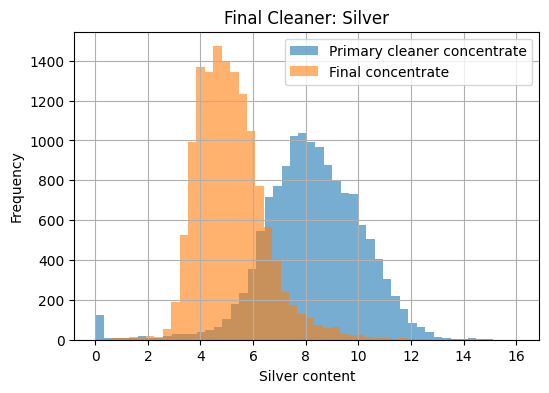


Primary cleaner concentrate — Silver
count    13795.000000
mean         8.229492
std          1.941196
min          0.010000
25%          7.113282
50%          8.231413
75%          9.513817
max         16.081632
Name: primary_cleaner.output.concentrate_ag, dtype: float64

Final concentrate — Silver
count    13795.000000
mean         5.165171
std          1.333297
min          0.010000
25%          4.222427
50%          5.005550
75%          5.862109
max         16.001945
Name: final.output.concentrate_ag, dtype: float64


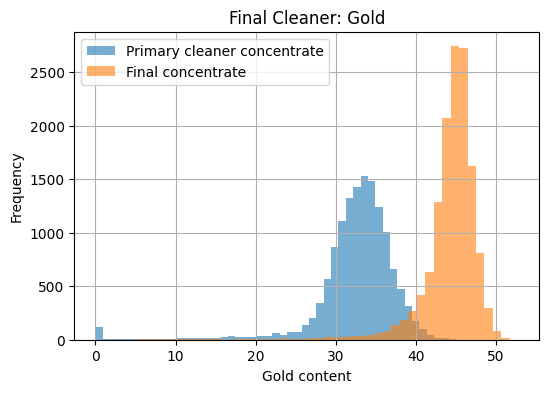


Primary cleaner concentrate — Gold
count    13795.000000
mean        32.476820
std          5.410135
min          0.010000
25%         30.836102
50%         33.196507
75%         35.322854
max         45.933934
Name: primary_cleaner.output.concentrate_au, dtype: float64

Final concentrate — Gold
count    13795.000000
mean        44.173624
std          3.980937
min          0.010000
25%         43.282622
50%         44.868073
75%         46.149205
max         52.756638
Name: final.output.concentrate_au, dtype: float64


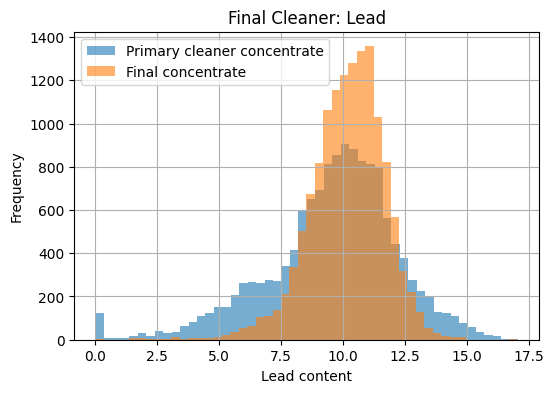


Primary cleaner concentrate — Lead
count    13795.000000
mean         9.587674
std          2.639700
min          0.010000
25%          8.304218
50%          9.903642
75%         11.279986
max         17.081278
Name: primary_cleaner.output.concentrate_pb, dtype: float64

Final concentrate — Lead
count    13795.000000
mean        10.175143
std          1.527930
min          0.010000
25%          9.301671
50%         10.306808
75%         11.183322
max         17.031899
Name: final.output.concentrate_pb, dtype: float64


In [22]:



metals = {
    'ag': 'Silver',
    'au': 'Gold',
    'pb': 'Lead'
}

for metal, metal_name in metals.items():
    plt.figure(figsize=(6, 4))

    # Primary cleaner output (input to final stage)
    train[f'primary_cleaner.output.concentrate_{metal}'].hist(
        bins=50, alpha=0.6, label='Primary cleaner concentrate'
    )

    # Final cleaner output
    train[f'final.output.concentrate_{metal}'].hist(
        bins=50, alpha=0.6, label='Final concentrate'
    )

    plt.title(f'Final Cleaner: {metal_name}')
    plt.xlabel(f'{metal_name} content')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    print(f"\nPrimary cleaner concentrate — {metal_name}")
    print(train[f'primary_cleaner.output.concentrate_{metal}'].describe())

    print(f"\nFinal concentrate — {metal_name}")
    print(train[f'final.output.concentrate_{metal}'].describe())

The dataset does not contain secondary cleaner concentrate values so we compared first cleaner to final output. While for silver it actually becomes less concentrate for gold it becomes more and for lead it stays the same.

# 2.2

Text(0.5, 1.0, 'Test Set - Feed Size')

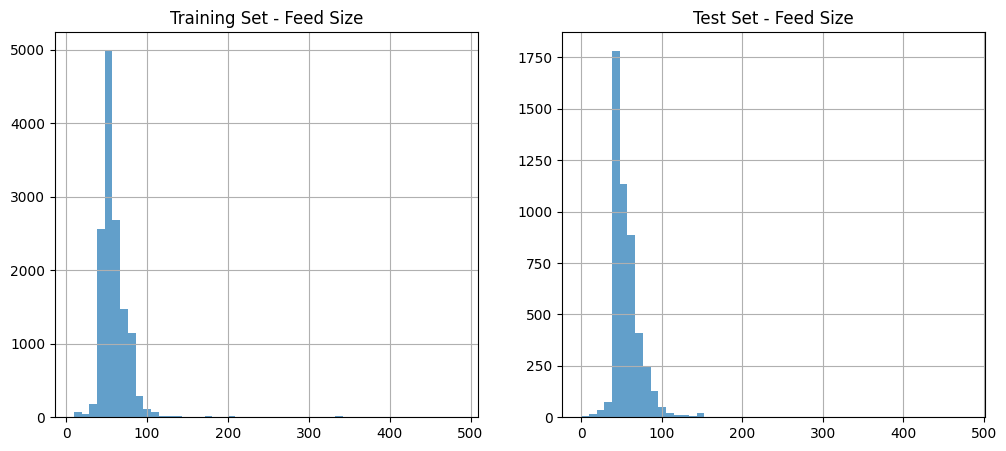

In [23]:


# Compare feed size distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
train['rougher.input.feed_size'].hist(bins=50, alpha=0.7)
plt.title('Training Set - Feed Size')

plt.subplot(1, 2, 2)
test['rougher.input.feed_size'].hist(bins=50, alpha=0.7)
plt.title('Test Set - Feed Size')



In [24]:
#overlay the grpahs

In [25]:
print(train['rougher.input.feed_size'].describe())

count    13795.000000
mean        59.983118
std         23.357018
min          9.659576
25%         48.976540
50%         55.377622
75%         65.908917
max        484.967466
Name: rougher.input.feed_size, dtype: float64


In [26]:
print(test['rougher.input.feed_size'].describe())


count    4855.000000
mean       56.778151
std        23.548748
min         0.046369
25%        44.011262
50%        51.509616
75%        62.879810
max       477.445473
Name: rougher.input.feed_size, dtype: float64


The feed particle size distributions in the training and test sets are very similar. Their means, medians, and spreads closely match, indicating no significant distribution shift that would bias model evaluation.

### 2.3


In [27]:
train['total_raw_feed'] = (train['rougher.input.feed_au'] + 
                          train['rougher.input.feed_ag'] + 
                          train['rougher.input.feed_pb'] + 
                          train['rougher.input.feed_sol'])

train['total_rougher_concentrate'] = (train['rougher.output.concentrate_au'] + 
                                     train['rougher.output.concentrate_ag'] + 
                                     train['rougher.output.concentrate_pb'] + 
                                     train['rougher.output.concentrate_sol'])

train['total_final_concentrate'] = (train['final.output.concentrate_au'] + 
                                   train['final.output.concentrate_ag'] + 
                                   train['final.output.concentrate_pb'] + 
                                   train['final.output.concentrate_sol'])

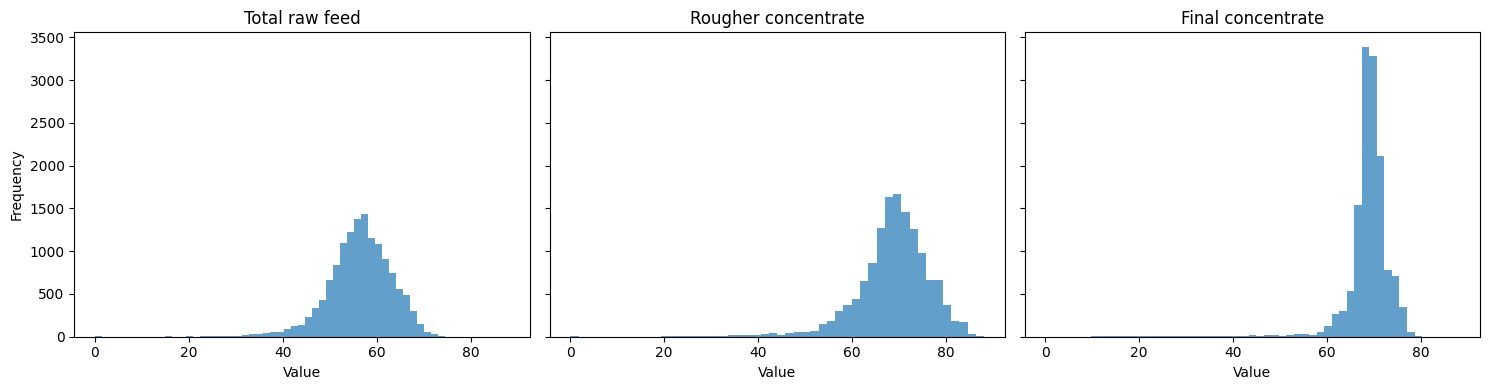

In [28]:


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

axes[0].hist(train['total_raw_feed'], bins=50, alpha=0.7)
axes[0].set_title('Total raw feed')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(train['total_rougher_concentrate'], bins=50, alpha=0.7)
axes[1].set_title('Rougher concentrate')
axes[1].set_xlabel('Value')

axes[2].hist(train['total_final_concentrate'], bins=50, alpha=0.7)
axes[2].set_title('Final concentrate')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()
# 
# plt.title(f'final cleaner: {metal.upper()} primary cleaner vs final output')
# plt.xlabel('Metal content')
# plt.ylabel('Frequency')
# plt.legend()
# plt.show()
#set x limit visualze so without nmber can see the change . xlimit


In [29]:
print(train['total_raw_feed'].dtype)

print(train['total_raw_feed'].describe())
print(train['total_rougher_concentrate'].describe())
print(train['total_final_concentrate'].describe())
print(test.shape)

float64
count    13795.000000
mean        56.220120
std          6.998622
min          0.040000
25%         52.543446
50%         56.618891
75%         60.761994
max         74.458253
Name: total_raw_feed, dtype: float64
count    13795.000000
mean        68.621375
std          8.085071
min          0.040000
25%         65.250312
50%         69.312323
75%         73.508433
max         88.140119
Name: total_rougher_concentrate, dtype: float64
count    13795.000000
mean        68.680828
std          5.418562
min          0.040000
25%         67.567504
50%         69.140939
75%         70.956585
max         80.210644
Name: total_final_concentrate, dtype: float64
(4855, 53)


The total concentration of substances increases significantly from the raw feed to the rougher concentrate, reflecting the initial enrichment of valuable components during flotation. The mean rises from approximately 56 in the raw feed to about 68 in the rougher concentrate, with the median showing a similar upward shift, indicating a broad improvement across the distribution rather than an effect driven by outliers. In the final concentrate, however, some metrics show a slight decrease. This reduction reflects the cleaning stage, where impurities are deliberately removed to improve purity, resulting in a smaller overall mass despite a higher gold grade. The interquartile ranges also shift upward from the raw feed to the rougher stage and then stabilize or narrow slightly in the final stage, confirming that purification prioritizes quality over quantity in the final output.

# 3.1

sMAPE = (1/N) × Σ |yi - ŷi| / ((|yi| + |ŷi|) / 2) × 100%
We need to predict both the rougher concentrate recovery and the final concentrate recovery, as these values represent the process efficiency at the intermediate and final stages of purification.

In [30]:
def smape(true_value, predicted_value):
    true_value = np.array(true_value)
    predicted_value = np.array(predicted_value)
    

    numerator = np.abs(true_value - predicted_value)
    denominator = (np.abs(true_value) + np.abs(predicted_value)) / 2

    return np.mean(numerator / denominator) * 100

In [31]:
def final_nmape(rougher, final):
    return .25*rougher + .75*(final)


# 3.2


In [32]:


X_rougher_train = train.drop(missing_in_test + [
    'date',
    'rougher.output.recovery',      
    'final.output.recovery',         
    'total_raw_feed',              
    'total_rougher_concentrate',    
    'total_final_concentrate'],
    axis=1)





X_final_train = train.drop(missing_in_test + [
    'date',
    'rougher.output.recovery',      
    'final.output.recovery',        
    'total_raw_feed',              
    'total_rougher_concentrate',    
    'total_final_concentrate'],
    axis=1)


# 
Y_rougher_train = train['rougher.output.recovery']

Y_final_train   = train['final.output.recovery']

# #test = test.drop('date', axis=1)
# print("X_rougher_train shape:", X_rougher_train.shape)
# print("y_rougher_train shape:", Y_rougher_train.shape)

# print("X_final_train shape:", X_final_train.shape)
# print("y_final_train shape:", Y_final_train.shape)


# test = test.drop('date', axis=1)
print(test.shape)
print(full.shape)






(4855, 53)
(18949, 87)


In [33]:
test = test.drop('date', axis=1)



In [34]:






# for depth in range(1, 21):
#     model = DecisionTreeRegressor(max_depth=depth, random_state=0)
#     model.fit(X_rougher_train, Y_rougher_train)
#     predictions = model.predict(test)
#     scores = cross_val_score(model, X_rougher_train, Y_rougher_train, cv=5)
#     print(depth, scores.mean())
#     print(smape(rough_target_test, predictions))


for depth in range(1, 21):
    model = DecisionTreeRegressor(max_depth=depth, random_state=0)

    
    # cross-validation score
    scores = cross_val_score(
        model, X_rougher_train, Y_rougher_train, cv=5
    )
    cv_score = scores.mean()
    
    # fit and predict on test
    model.fit(X_rougher_train, Y_rougher_train)
    predictions = model.predict(test)
    smape_score = smape(rough_target_test, predictions)
    
    print(
        f"Depth={depth:2d} | CV score={cv_score:.4f} | sMAPE={smape_score:.2f}"
    )





Depth= 1 | CV score=-0.4861 | sMAPE=9.75
Depth= 2 | CV score=-0.3493 | sMAPE=10.21
Depth= 3 | CV score=-0.2043 | sMAPE=10.52
Depth= 4 | CV score=-0.3095 | sMAPE=11.07
Depth= 5 | CV score=-0.4342 | sMAPE=11.73
Depth= 6 | CV score=-1.0028 | sMAPE=11.97
Depth= 7 | CV score=-1.0978 | sMAPE=11.76
Depth= 8 | CV score=-0.9902 | sMAPE=11.92
Depth= 9 | CV score=-1.3481 | sMAPE=12.19
Depth=10 | CV score=-1.1285 | sMAPE=12.48
Depth=11 | CV score=-1.3860 | sMAPE=12.57
Depth=12 | CV score=-1.2220 | sMAPE=12.54
Depth=13 | CV score=-1.1953 | sMAPE=12.95
Depth=14 | CV score=-1.6477 | sMAPE=12.61
Depth=15 | CV score=-1.4660 | sMAPE=12.73
Depth=16 | CV score=-1.3993 | sMAPE=13.07
Depth=17 | CV score=-1.4532 | sMAPE=12.88
Depth=18 | CV score=-1.4374 | sMAPE=12.92
Depth=19 | CV score=-1.6255 | sMAPE=13.09
Depth=20 | CV score=-1.7039 | sMAPE=13.10


In [35]:



# print(test['date'])



model = LinearRegression()
model = model.fit(X_rougher_train, Y_rougher_train)
predictions = model.predict(test)
scores = cross_val_score(model, X_rougher_train, Y_rougher_train, cv=5)
final_score = scores.mean()
print('Average model evaluation score:', final_score)
print('smape', smape(rough_target_test, predictions))




Average model evaluation score: -0.271954057670851
smape 10.584338461072969


In [36]:




# for est in range(10, 51, 10):
#     for depth in range (1, 11):
#         model = RandomForestRegressor(
#     n_estimators=est,
#     max_depth=depth,
#     random_state=12345
#     )
#         model = model.fit(X_rougher_train, Y_rougher_train)
#         rougher_predictions_1 = model.predict(test)
        
#         print(smape(rough_target_test, rougher_predictions_1))



for est in range(10, 51, 10):
    for depth in range(1, 11):
        
        model = RandomForestRegressor(
            n_estimators=est,
            max_depth=depth,
            random_state=12345
        )
        
        # cross-validation
        cv_scores = cross_val_score(
            model,
            X_rougher_train,
            Y_rougher_train,
            cv=5
        )
        cv_mean = cv_scores.mean()
        
        # fit and predict
        model.fit(X_rougher_train, Y_rougher_train)
        predictions = model.predict(test)
        smape_score = smape(rough_target_test, predictions)
        
        print(
            f"Estimators={est:2d} | Depth={depth:2d} | "
            f"CV={cv_mean:.4f} | sMAPE={smape_score:.2f}"
        )

Estimators=10 | Depth= 1 | CV=-0.3426 | sMAPE=9.76
Estimators=10 | Depth= 2 | CV=-0.1841 | sMAPE=10.15
Estimators=10 | Depth= 3 | CV=-0.0942 | sMAPE=10.54
Estimators=10 | Depth= 4 | CV=-0.1097 | sMAPE=11.13
Estimators=10 | Depth= 5 | CV=-0.0689 | sMAPE=11.44
Estimators=10 | Depth= 6 | CV=-0.1045 | sMAPE=11.56
Estimators=10 | Depth= 7 | CV=-0.1367 | sMAPE=11.41
Estimators=10 | Depth= 8 | CV=-0.2035 | sMAPE=11.46
Estimators=10 | Depth= 9 | CV=-0.2485 | sMAPE=11.51
Estimators=10 | Depth=10 | CV=-0.2776 | sMAPE=11.62
Estimators=20 | Depth= 1 | CV=-0.3594 | sMAPE=9.75
Estimators=20 | Depth= 2 | CV=-0.1900 | sMAPE=10.14
Estimators=20 | Depth= 3 | CV=-0.0947 | sMAPE=10.49
Estimators=20 | Depth= 4 | CV=-0.0967 | sMAPE=11.09
Estimators=20 | Depth= 5 | CV=-0.0475 | sMAPE=11.37
Estimators=20 | Depth= 6 | CV=-0.0649 | sMAPE=11.43
Estimators=20 | Depth= 7 | CV=-0.0678 | sMAPE=11.47
Estimators=20 | Depth= 8 | CV=-0.0760 | sMAPE=11.52
Estimators=20 | Depth= 9 | CV=-0.1267 | sMAPE=11.47
Estimators=20 

In [37]:

model_train = RandomForestRegressor(
    n_estimators=20,
    max_depth=1,
    random_state=12345
    )
model_train = model_train.fit(X_rougher_train, Y_rougher_train)
train_predictions_1 = model_train.predict(test)
scores_1 = cross_val_score(model_train, X_rougher_train, Y_rougher_train, cv=5)
final_score_1 = scores_1.mean()
print('Average model evaluation score:', final_score_1)
print(smape(rough_target_test, train_predictions_1))

Average model evaluation score: -0.3594471214467484
9.748371022602772


In [38]:
smape_rougher = smape(rough_target_test, train_predictions_1)
print(smape(rough_target_test, train_predictions_1))

9.748371022602772


In [39]:
model_test = RandomForestRegressor(
    n_estimators=20,
    max_depth=1,
    random_state=12345
    )
model_test = model_test.fit(X_final_train, Y_final_train)
test_predictions_1 = model_test.predict(test)
scores_1 = cross_val_score(model_test, X_final_train, Y_final_train, cv=5)
final_score_1 = scores_1.mean()
print('Average model evaluation score:', final_score_1)
print(smape(rough_target_test, test_predictions_1))


Average model evaluation score: 0.024101559105159497
16.64614189796267


In [40]:

smape_final = smape(final_target_test, test_predictions_1)
print(smape(final_target_test, test_predictions_1))


11.3388217780508


In [41]:
print(final_nmape(smape_rougher, smape_final))




10.941209089188792


The best model was random forest with 20 estimators and depth = 1. The weighted final metric (0.25 × rougher + 0.75 × final) of 10.94% represents excellent predictive accuracy for industrial process control. sMAPE values below 15% are generally considered very good for recovery prediction tasks, and the results fall well within this range.